# Curated MIMIC-III Analysis 


In [1]:
import warnings
from pathlib import Path

from IPython.display import display

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style('whitegrid')


# Setup

In [2]:
# Runtime configuration
CURATED_ROOT = Path('..') / 'data' / 'curated'
DATAFILE_NAME = 'all_hourly_data.h5'

# Variants to compare against baseline
SCENARIOS = [
    'age35_range5','age35_range10','age35_range15',
    'age45_range5','age45_range10','age45_range15',
    'age55_range5','age55_range10','age55_range15',
    'min48hr','min18age','minperc5',
]

AGG_METHODS = [
    'mean','median','standard deviation','mean deviation','maximum deviation'
]

LABELS = ['icu','mortality']
SEEDS = [22,985,439,81]
TEST_SIZE = 0.2

# Use the full cohort (no downsampling)
MAX_RECORDS_PER_SCENARIO = None

MODEL_KWARGS = dict(max_iter=500, solver='liblinear', random_state=0)
FALLBACK_BASELINE_SCENARIO = 'baseline_nofilters'

print('Curated root:', CURATED_ROOT.resolve())
print('Variants:', len(SCENARIOS))


Curated root: /home/ccampb47/work/MIMIC_Extract/data/curated
Variants: 12


In [3]:
def _get_time_level_name(x_index):
    names = list(x_index.names)
    for candidate in ['hours_in','time','hour','Hour']:
        if candidate in names:
            return candidate
    return names[-1]

def _record_id_levels(x_index):
    t = _get_time_level_name(x_index)
    return [n for n in x_index.names if n != t]

def _select_pos_label(patients_df, target_label):
    if target_label == 'icu':
        return patients_df['mort_icu'].astype(int)
    if target_label == 'mortality':
        if 'mort_hosp' in patients_df.columns:
            return patients_df['mort_hosp'].astype(int)
        if 'hospital_expire_flag' in patients_df.columns:
            return patients_df['hospital_expire_flag'].astype(int)
        raise KeyError('No mortality column found in patients_df')
    raise ValueError('Unknown target label')


# Variant loader 

In [4]:
def _pick_datafile(scenario_dir):
    candidates = ['all_hourly_data.h5', 'all_hourly_data_5000.h5', 'all_hourly_data_2000.h5']
    for c in candidates:
        fp = scenario_dir / c
        if fp.exists():
            return fp
    raise FileNotFoundError(f'No all_hourly_data*.h5 found in {scenario_dir}')

def load_curated_scenario(scenario_name, data_root=CURATED_ROOT, load_X=True):
    scenario_dir = data_root / scenario_name
    datafile = _pick_datafile(scenario_dir)

    X = None
    if load_X:
        # Note: vitals_labs is stored in fixed format (can't efficiently filter rows on read).
        # We therefore rely on subsetting rows *after* read and on downsampling the number of records.
        X = pd.read_hdf(str(datafile), 'vitals_labs')

    patients = pd.read_hdf(str(datafile), 'patients')

    try:
        interventions = pd.read_hdf(str(datafile), 'interventions')
    except Exception:
        interventions = None

    return {
        'name': scenario_name,
        'X': X,
        'patients': patients,
        'interventions': interventions,
        'datafile': datafile,
    }

def maybe_sample_record_ids(patients_df, max_records):
    if max_records is None:
        return patients_df
    if len(patients_df) <= max_records:
        return patients_df
    return patients_df.sample(max_records, random_state=0)

def subset_X_by_patients(X, patients_df):
    """Return only time-series rows whose (subject_id,hadm_id,icustay_id) are in patients_df.

    This reduces groupby workload even though `vitals_labs` itself is read in fixed format.

    Assumes X index contains `hours_in` (or one time level) plus record id levels.
    """
    time_level = _get_time_level_name(X.index)
    rec_index = X.index.droplevel(time_level)
    keep = rec_index.isin(patients_df.index)
    return X[keep]

VARIANT_OBJS = []
for s in SCENARIOS:
    print('Loading patients only:', s)
    obj = load_curated_scenario(s, load_X=False)
    obj['patients'] = maybe_sample_record_ids(obj['patients'], MAX_RECORDS_PER_SCENARIO)
    VARIANT_OBJS.append(obj)
print('Loaded variants:', [v['name'] for v in VARIANT_OBJS])


Loading patients only: age35_range5


Loading patients only: age35_range10


Loading patients only: age35_range15


Loading patients only: age45_range5


Loading patients only: age45_range10


...

Loading patients only: age55_range15


Loading patients only: min48hr


Loading patients only: min18age


Loading patients only: minperc5


Loaded variants: ['age35_range5', 'age35_range10', 'age35_range15', 'age45_range5', 'age45_range10', 'age45_range15', 'age55_range5', 'age55_range10', 'age55_range15', 'min48hr', 'min18age', 'minperc5']


# Baseline loader 

In [5]:
# Baseline: load from a curated scenario directly (skips DuckDB export)
BASELINE = load_curated_scenario(FALLBACK_BASELINE_SCENARIO, load_X=True)
BASELINE['patients'] = maybe_sample_record_ids(BASELINE['patients'], MAX_RECORDS_PER_SCENARIO)
print('Baseline:', BASELINE['name'], 'X:', BASELINE['X'].shape, 'patients:', BASELINE['patients'].shape)


Baseline: baseline_nofilters X: (2200954, 21) patients: (34472, 29)


# Lens plots 

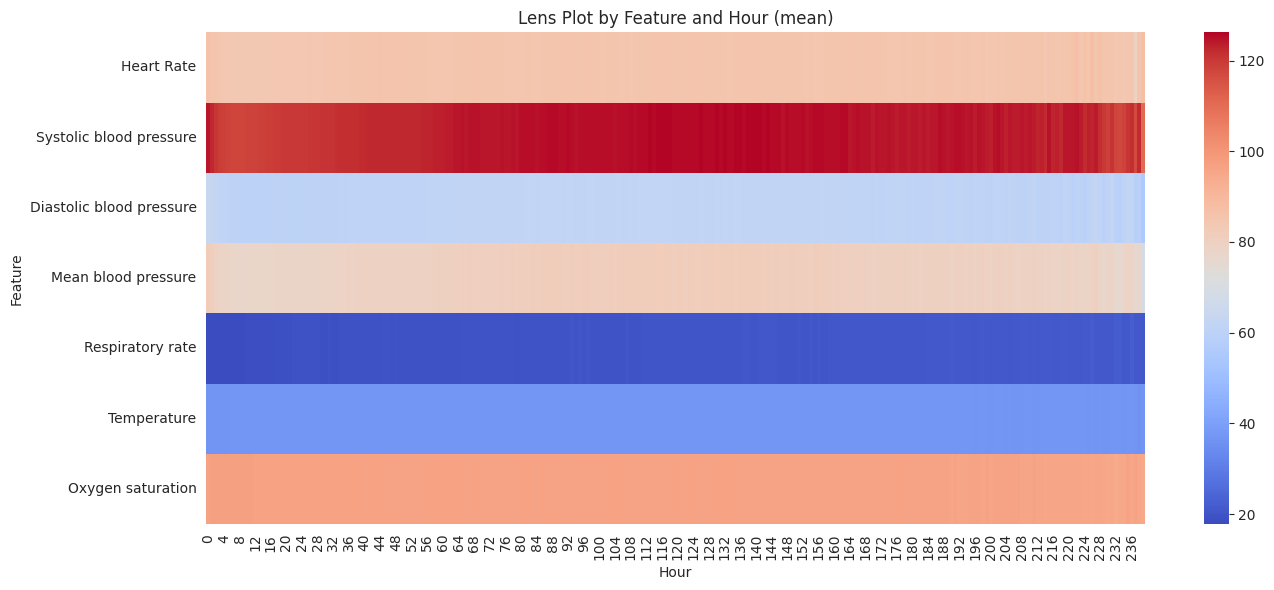

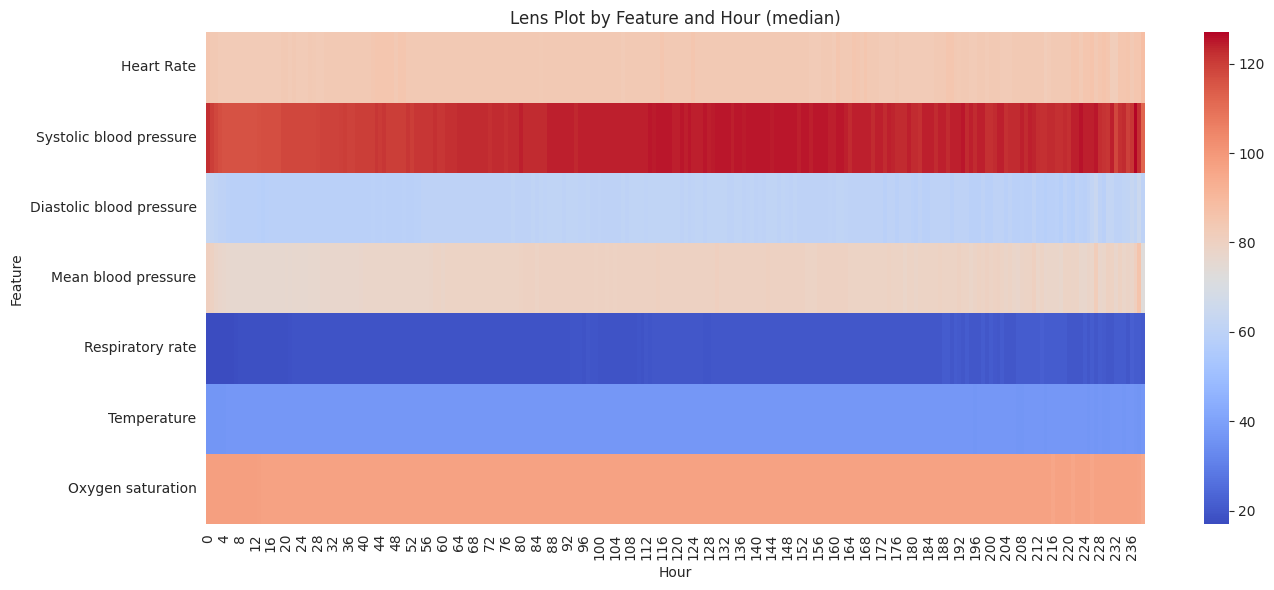

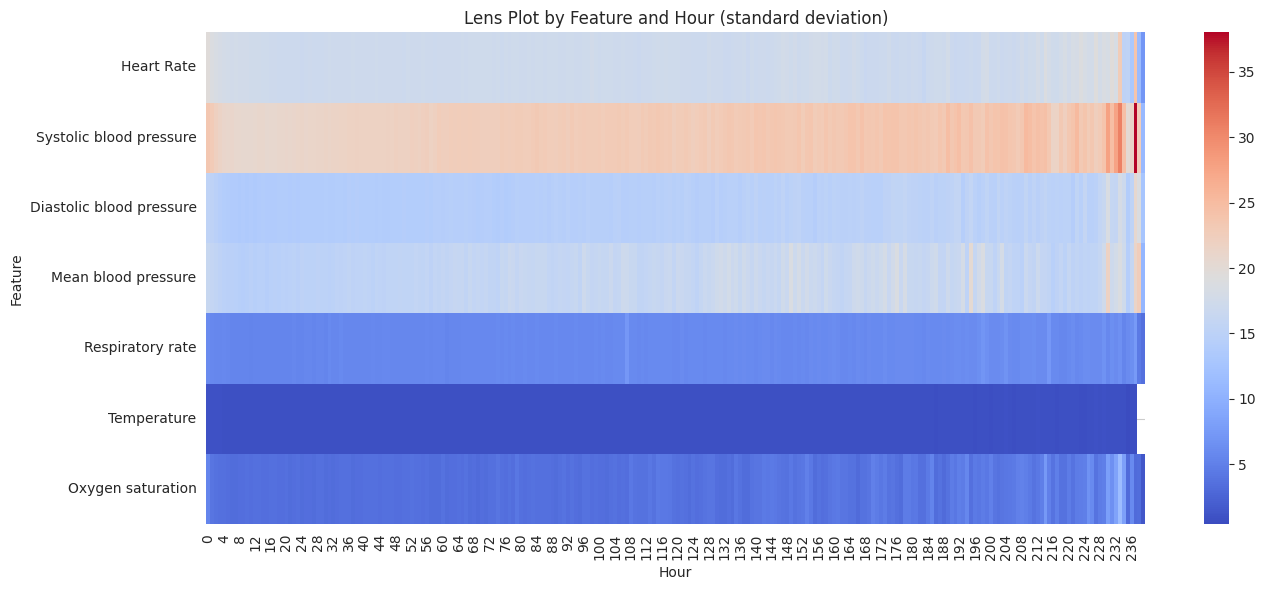

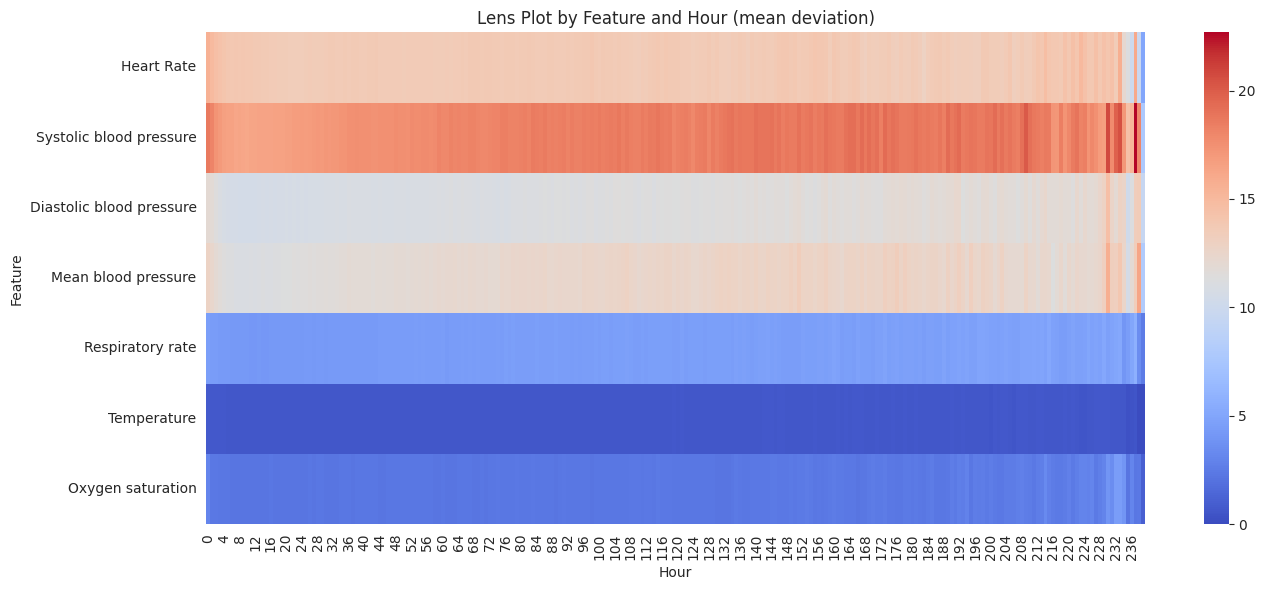

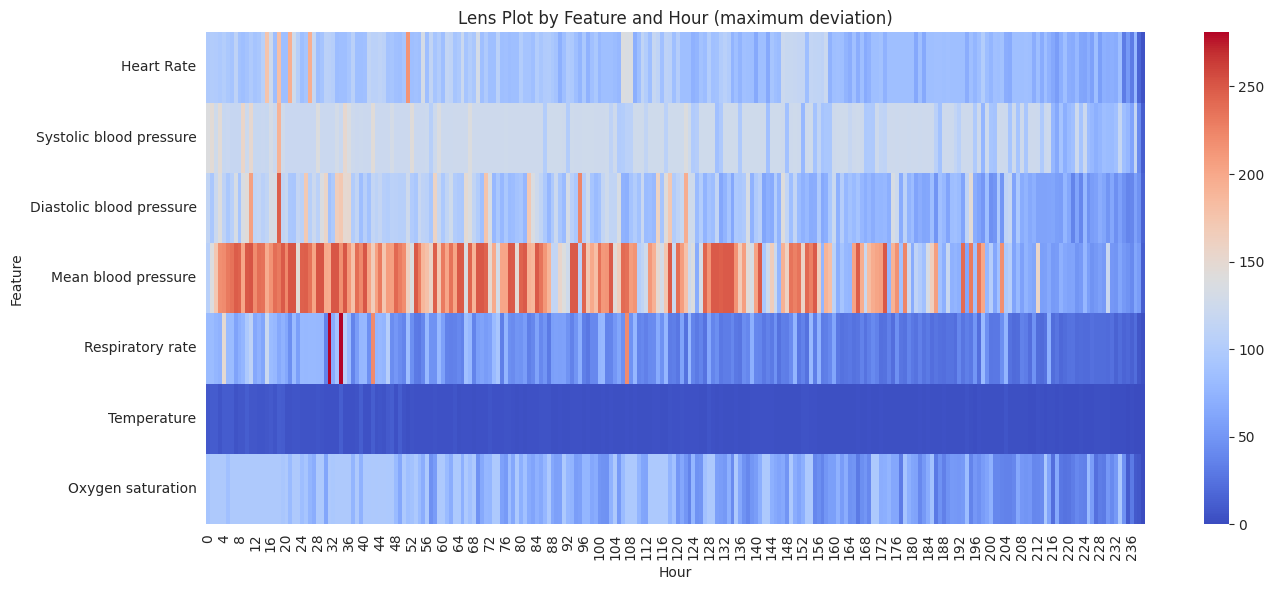

In [6]:
LENS_FEATURES = [
    'Heart Rate',
    'Systolic blood pressure',
    'Diastolic blood pressure',
    'Mean blood pressure',
    'Respiratory rate',
    'Temperature',
    'Oxygen saturation',
]

def _find_feature_name(feature_map, target_name):
    # Prefer exact case-insensitive match first.
    key = target_name.lower()
    if key in feature_map:
        return feature_map[key]

    # Fallback aliases for common naming variations.
    aliases = {
        'Heart Rate': ['heart rate', 'heartrate', 'pulse'],
        'Systolic blood pressure': ['systolic blood pressure', 'sbp'],
        'Diastolic blood pressure': ['diastolic blood pressure', 'dbp'],
        'Mean blood pressure': ['mean blood pressure', 'map'],
        'Respiratory rate': ['respiratory rate', 'resp rate', 'rr'],
        'Temperature': ['temperature', 'temp'],
        'Oxygen saturation': ['oxygen saturation', 'spo2', 'o2 saturation'],
    }.get(target_name, [target_name.lower()])

    for alias in aliases:
        if alias in feature_map:
            return feature_map[alias]
    return None

def _aggregate_series_by_hour(series, hour_values, method):
    s = pd.Series(series.values, index=hour_values)
    if method == 'mean':
        return s.groupby(level=0).mean()
    if method == 'median':
        return s.groupby(level=0).median()
    if method == 'standard deviation':
        return s.groupby(level=0).std(ddof=1)
    if method == 'mean deviation':
        return s.groupby(level=0).apply(lambda x: (x - x.mean()).abs().mean())
    if method == 'maximum deviation':
        return s.groupby(level=0).apply(lambda x: (x - x.mean()).abs().max())
    raise ValueError(f'Unknown method: {method}')

def build_lens_feature_hour_matrix(X, method, requested_features):
    if not isinstance(X.columns, pd.MultiIndex):
        raise ValueError('Expected MultiIndex columns in vitals_labs data.')

    time_level = _get_time_level_name(X.index)
    hour_values = X.index.get_level_values(time_level)
    all_hours = np.sort(np.asarray(pd.Index(hour_values).unique(), dtype=int))

    # Use only "mean" measurements as the per-hour value for each feature.
    mean_cols = [c for c in X.columns if str(c[1]).lower() == 'mean']
    feature_map = {str(c[0]).lower(): str(c[0]) for c in mean_cols}

    matrix_rows = []
    missing_features = []

    for requested in requested_features:
        actual = _find_feature_name(feature_map, requested)
        if actual is None:
            matrix_rows.append(pd.Series(np.nan, index=all_hours, name=requested))
            missing_features.append(requested)
            continue

        col = next(c for c in mean_cols if str(c[0]) == actual)
        agg = _aggregate_series_by_hour(X[col], hour_values, method)
        agg = agg.reindex(all_hours)
        matrix_rows.append(pd.Series(agg.values, index=all_hours, name=requested))

    matrix = pd.DataFrame(matrix_rows, index=requested_features)
    matrix.columns.name = 'Hour'
    matrix.index.name = 'Feature'
    return matrix, missing_features

def plot_lens_feature_hour_heatmap(matrix, method, missing_features):
    plt.figure(figsize=(14, 6))
    sns.heatmap(matrix, cmap='coolwarm')
    plt.title(f'Lens Plot by Feature and Hour ({method})')
    plt.xlabel('Hour')
    plt.ylabel('Feature')
    if missing_features:
        missing_text = ', '.join(missing_features)
        plt.figtext(0.01, 0.01, f'Missing in dataset: {missing_text}', ha='left', fontsize=9)
    plt.tight_layout()
    plt.show()

# Build lens plots from baseline vitals_labs data.
base_pat = maybe_sample_record_ids(BASELINE['patients'], MAX_RECORDS_PER_SCENARIO)
X_base_small = subset_X_by_patients(BASELINE['X'], base_pat)

for method in AGG_METHODS:
    matrix, missing = build_lens_feature_hour_matrix(X_base_small, method, LENS_FEATURES)
    plot_lens_feature_hour_heatmap(matrix, method, missing)


# Record-level feature aggregation 

In [7]:
def build_record_aggregated_features(X, method):
    time_level = _get_time_level_name(X.index)
    rec_levels = _record_id_levels(X.index)
    g = X.groupby(level=rec_levels)
    if method == 'mean':
        return g.mean()
    if method == 'median':
        return g.median()
    if method == 'standard deviation':
        return g.std(ddof=1)
    if method == 'mean deviation':
        def _mean_dev(df):
            m = df.mean(axis=0)
            return (df.sub(m, axis=1).abs()).mean(axis=0)
        return g.apply(_mean_dev)
    if method == 'maximum deviation':
        def _max_dev(df):
            m = df.mean(axis=0)
            return (df.sub(m, axis=1).abs()).max(axis=0)
        return g.apply(_max_dev)
    raise ValueError(f'Unknown method: {method}')


# McNemar evaluation + significance 

Evaluating variant=age35_range5 target=icu method=mean


Evaluating variant=age35_range10 target=icu method=mean


Evaluating variant=age35_range15 target=icu method=mean


Evaluating variant=age45_range5 target=icu method=mean
Evaluating variant=age45_range10 target=icu method=mean


Evaluating variant=age45_range15 target=icu method=mean


...

Evaluating variant=min48hr target=icu method=mean


Evaluating variant=min18age target=icu method=mean


Evaluating variant=minperc5 target=icu method=mean


Icu McNemar Results Using Mean Aggregation


,Filter Name,Avg Train Acc,Avg Test Acc,Avg Train Precision,Avg Test Precision,Avg Train Recall,Avg Test Recall,Avg Train F1,Avg Test F1,"McNemar (Stat, p)"
0,raw,0.946976,0.948078,0.770350,0.780938,0.273079,0.288717,0.403211,0.421357,—
1,age35_range5,0.976730,0.978989,0.850000,0.833333,0.374708,0.454167,0.517713,0.567857,0.4 (p=5.000e-01)
2,age35_range10,0.973788,0.967284,0.874495,0.684524,0.248538,0.332246,0.384600,0.443723,0.7 (p=2.500e-01)
3,age35_range15,0.973048,0.968993,0.823409,0.736111,0.257871,0.262228,0.392054,0.384048,2.5 (p=1.562e-02)
4,age45_range5,0.972172,0.974358,0.883982,0.758036,0.410947,0.422917,0.559294,0.532037,0.6 (p=1.250e-01)
5,age45_range10,0.968580,0.972855,0.823156,0.779789,0.373042,0.416967,0.512754,0.541253,0.4 (p=2.500e-01)
6,age45_range15,0.965405,0.970636,0.766932,0.795474,0.319237,0.395286,0.450609,0.526775,0.4 (p=3.750e-01)
7,age55_range5,0.959301,0.957795,0.687101,0.666071,0.310222,0.289377,0.427335,0.397672,1.8 (p=7.812e-03)
8,age55_range10,0.961149,0.956796,0.757120,0.810301,0.234463,0.246538,0.357762,0.376396,4.8 (p=1.953e-03)
9,age55_range15,0.959548,0.959160,0.768979,0.812313,0.263657,0.283166,0.392609,0.418253,2.5 (p=3.125e-02)


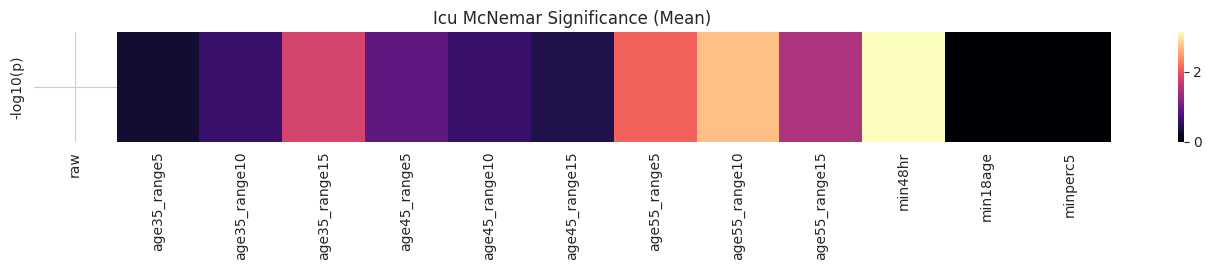

Evaluating variant=age35_range5 target=mortality method=mean


Evaluating variant=age35_range10 target=mortality method=mean


Evaluating variant=age35_range15 target=mortality method=mean


Evaluating variant=age45_range5 target=mortality method=mean


Evaluating variant=age45_range10 target=mortality method=mean


...

Evaluating variant=min48hr target=mortality method=mean


Evaluating variant=min18age target=mortality method=mean


Evaluating variant=minperc5 target=mortality method=mean


Mortality McNemar Results Using Mean Aggregation


,Filter Name,Avg Train Acc,Avg Test Acc,Avg Train Precision,Avg Test Precision,Avg Train Recall,Avg Test Recall,Avg Train F1,Avg Test F1,"McNemar (Stat, p)"
0,raw,0.918437,0.918637,0.794103,0.791654,0.201097,0.205371,0.320910,0.325974,—
1,age35_range5,0.972839,0.968420,0.975000,0.583333,0.363426,0.193750,0.528852,0.282197,0.1 (p=5.000e-01)
2,age35_range10,0.964126,0.960957,0.870536,0.602679,0.229886,0.249145,0.363077,0.350138,0.5 (p=2.500e-01)
3,age35_range15,0.964391,0.960406,0.869558,0.681746,0.228403,0.215950,0.361454,0.326042,1.2 (p=3.125e-02)
4,age45_range5,0.955959,0.956820,0.800238,0.761364,0.291027,0.342657,0.424239,0.456101,0.7 (p=1.250e-01)
5,age45_range10,0.952906,0.954927,0.846081,0.777183,0.262683,0.274583,0.399486,0.405271,0.0 (p=6.875e-01)
6,age45_range15,0.951117,0.952953,0.834698,0.754302,0.245092,0.261691,0.378726,0.388293,0.2 (p=4.240e-01)
7,age55_range5,0.943333,0.943756,0.804715,0.826786,0.264324,0.238131,0.397822,0.365068,0.1 (p=6.250e-01)
8,age55_range10,0.942045,0.943263,0.833192,0.810186,0.209421,0.206793,0.334249,0.321341,2.1 (p=3.125e-02)
9,age55_range15,0.940464,0.939528,0.832036,0.793569,0.211508,0.204170,0.337222,0.322321,0.8 (p=6.250e-02)


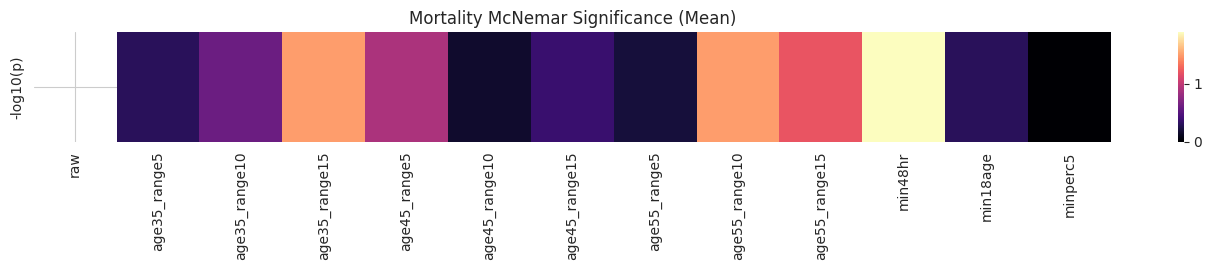

In [8]:
def mcnemar_test(pred_base, pred_variant):
    a = np.asarray(pred_base).astype(int)
    b = np.asarray(pred_variant).astype(int)
    n01 = int(np.sum((a == 0) & (b == 1)))
    n10 = int(np.sum((a == 1) & (b == 0)))
    stat = (abs(n01 - n10) - 1.0) ** 2 / (n01 + n10) if (n01 + n10) > 0 else 0.0
    # Exact binomial (fallback to NaN if scipy missing)
    try:
        from scipy.stats import binom
        n = n01 + n10
        if n == 0:
            p = 1.0
        else:
            p_one = binom.cdf(min(n01, n10), n, 0.5)
            p = min(1.0, 2.0 * p_one)
    except Exception:
        p = np.nan
    return stat, p

def impute_and_scale(X):
    X = X.replace([np.inf, -np.inf], np.nan)
    col_means = X.mean(axis=0, skipna=True)
    # If a feature column is entirely missing after subsetting, `col_means` will be NaN.
    # Replace those with 0 so downstream estimators never see NaNs.
    col_means = col_means.fillna(0.0)
    X = X.fillna(col_means)
    X = X.fillna(0.0)
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X.values)
    return Xs, scaler, col_means

def evaluate_for_method(method, target_label, max_variants=None):
    base_pat = maybe_sample_record_ids(BASELINE['patients'], MAX_RECORDS_PER_SCENARIO)
    y_base = _select_pos_label(base_pat, target_label)

    # Subset time-series before aggregation
    X_base_full = BASELINE['X']
    X_base_small = subset_X_by_patients(X_base_full, base_pat)
    X_base_agg = build_record_aggregated_features(X_base_small, method).loc[base_pat.index]

    raw_metrics = {
        'train_acc':[], 'test_acc':[],
        'train_precision':[], 'test_precision':[],
        'train_recall':[], 'test_recall':[],
        'train_f1':[], 'test_f1':[]
    }
    raw_preds_by_seed = {}

    idx = X_base_agg.index
    for seed in SEEDS:
        train_ids, test_ids = train_test_split(
            idx,
            test_size=TEST_SIZE,
            random_state=seed,
            stratify=y_base.loc[idx].values,
        )
        X_tr = X_base_agg.loc[train_ids]
        X_te = X_base_agg.loc[test_ids]
        y_tr = y_base.loc[train_ids].values
        y_te = y_base.loc[test_ids].values

        X_trs, scaler, col_means = impute_and_scale(X_tr)
        X_te = X_te.replace([np.inf, -np.inf], np.nan)
        X_te = X_te.fillna(col_means)
        X_te = X_te.fillna(0.0)
        X_tes = scaler.transform(X_te.values)

        clf = LogisticRegression(**MODEL_KWARGS)
        # LogisticRegression requires at least two classes in training.
        if len(np.unique(y_tr)) < 2:
            continue
        clf.fit(X_trs, y_tr)

        pred_tr = clf.predict(X_trs)
        pred_te = clf.predict(X_tes)

        raw_metrics['train_acc'].append(accuracy_score(y_tr, pred_tr))
        raw_metrics['test_acc'].append(accuracy_score(y_te, pred_te))
        raw_metrics['train_precision'].append(precision_score(y_tr, pred_tr, zero_division=0))
        raw_metrics['test_precision'].append(precision_score(y_te, pred_te, zero_division=0))
        raw_metrics['train_recall'].append(recall_score(y_tr, pred_tr, zero_division=0))
        raw_metrics['test_recall'].append(recall_score(y_te, pred_te, zero_division=0))
        raw_metrics['train_f1'].append(f1_score(y_tr, pred_tr, zero_division=0))
        raw_metrics['test_f1'].append(f1_score(y_te, pred_te, zero_division=0))

        raw_preds_by_seed[seed] = (test_ids, pred_te)

    results = {
        'raw': {
            'train_acc': float(np.mean(raw_metrics['train_acc'])),
            'test_acc': float(np.mean(raw_metrics['test_acc'])),
            'train_precision': float(np.mean(raw_metrics['train_precision'])),
            'test_precision': float(np.mean(raw_metrics['test_precision'])),
            'train_recall': float(np.mean(raw_metrics['train_recall'])),
            'test_recall': float(np.mean(raw_metrics['test_recall'])),
            'train_f1': float(np.mean(raw_metrics['train_f1'])),
            'test_f1': float(np.mean(raw_metrics['test_f1'])),
            'mcnemar': None,
        }
    }

    variants = VARIANT_OBJS if max_variants is None else VARIANT_OBJS[:max_variants]
    for v in variants:
        print(f'Evaluating variant={v["name"]} target={target_label} method={method}')
        v_pat = maybe_sample_record_ids(v['patients'], MAX_RECORDS_PER_SCENARIO)
        y_v = _select_pos_label(v_pat, target_label)

        # Load X only for the current variant, then immediately subset it.
        X_v_full = v.get('X', None)
        if X_v_full is None:
            X_v_full = pd.read_hdf(str(v['datafile']), 'vitals_labs')
        X_v_small = subset_X_by_patients(X_v_full, v_pat)
        X_v_agg = build_record_aggregated_features(X_v_small, method).loc[v_pat.index]

        metrics = {
            'train_acc':[], 'test_acc':[],
            'train_precision':[], 'test_precision':[],
            'train_recall':[], 'test_recall':[],
            'train_f1':[], 'test_f1':[]
        }
        mstats = []

        idx_v = X_v_agg.index
        for seed in SEEDS:
            if seed not in raw_preds_by_seed:
                continue
            base_test_ids, base_pred = raw_preds_by_seed[seed]
            test_ids_v = v_pat.index.intersection(base_test_ids)
            if len(test_ids_v) < 10:
                continue

            train_ids_v = v_pat.index.difference(test_ids_v)
            if len(train_ids_v) < 10:
                continue

            X_tr = X_v_agg.loc[train_ids_v]
            X_te = X_v_agg.loc[test_ids_v]
            y_tr = y_v.loc[train_ids_v].values
            y_te = y_v.loc[test_ids_v].values

            X_trs, scaler, col_means = impute_and_scale(X_tr)
            X_te = X_te.replace([np.inf, -np.inf], np.nan)
            X_te = X_te.fillna(col_means)
            X_te = X_te.fillna(0.0)
            X_tes = scaler.transform(X_te.values)

            clf = LogisticRegression(**MODEL_KWARGS)
            # LogisticRegression requires at least two classes in training.
            if len(np.unique(y_tr)) < 2:
                continue
            clf.fit(X_trs, y_tr)
            pred_tr = clf.predict(X_trs)
            pred_te = clf.predict(X_tes)

            metrics['train_acc'].append(accuracy_score(y_tr, pred_tr))
            metrics['test_acc'].append(accuracy_score(y_te, pred_te))
            metrics['train_precision'].append(precision_score(y_tr, pred_tr, zero_division=0))
            metrics['test_precision'].append(precision_score(y_te, pred_te, zero_division=0))
            metrics['train_recall'].append(recall_score(y_tr, pred_tr, zero_division=0))
            metrics['test_recall'].append(recall_score(y_te, pred_te, zero_division=0))
            metrics['train_f1'].append(f1_score(y_tr, pred_tr, zero_division=0))
            metrics['test_f1'].append(f1_score(y_te, pred_te, zero_division=0))

            base_pred_map = pd.Series(base_pred, index=pd.Index(base_test_ids))
            var_pred_map = pd.Series(pred_te, index=pd.Index(test_ids_v))
            common_ids = test_ids_v
            stat, p = mcnemar_test(base_pred_map.loc[common_ids].values, var_pred_map.loc[common_ids].values)
            mstats.append((stat, p))

        results[v['name']] = {
            'train_acc': float(np.mean(metrics['train_acc'])) if metrics['train_acc'] else np.nan,
            'test_acc': float(np.mean(metrics['test_acc'])) if metrics['test_acc'] else np.nan,
            'train_precision': float(np.mean(metrics['train_precision'])) if metrics['train_precision'] else np.nan,
            'test_precision': float(np.mean(metrics['test_precision'])) if metrics['test_precision'] else np.nan,
            'train_recall': float(np.mean(metrics['train_recall'])) if metrics['train_recall'] else np.nan,
            'test_recall': float(np.mean(metrics['test_recall'])) if metrics['test_recall'] else np.nan,
            'train_f1': float(np.mean(metrics['train_f1'])) if metrics['train_f1'] else np.nan,
            'test_f1': float(np.mean(metrics['test_f1'])) if metrics['test_f1'] else np.nan,
            'mcnemar': (
                float(np.mean([s for s,_ in mstats])) if mstats else np.nan,
                float(np.min([p for _,p in mstats])) if mstats else np.nan,
            ),
        }

        # Free large arrays
        try:
            del X_v_full, X_v_small, X_v_agg
        except Exception:
            pass

    return results

def show_results(results_dict, target_label, method):
    names = ['raw'] + [n for n in results_dict.keys() if n != 'raw']
    rows = []
    for name in names:
        r = results_dict[name]
        if name == 'raw' or r['mcnemar'] is None:
            m_str = '—'
        else:
            stat, p = r['mcnemar']
            m_str = f'{stat:.1f} (p={p:.3e})'
        rows.append([
            name,
            r['train_acc'],
            r['test_acc'],
            r['train_precision'],
            r['test_precision'],
            r['train_recall'],
            r['test_recall'],
            r['train_f1'],
            r['test_f1'],
            m_str,
        ])
    df = pd.DataFrame(
        rows,
        columns=[
            'Filter Name',
            'Avg Train Acc',
            'Avg Test Acc',
            'Avg Train Precision',
            'Avg Test Precision',
            'Avg Train Recall',
            'Avg Test Recall',
            'Avg Train F1',
            'Avg Test F1',
            'McNemar (Stat, p)'
        ]
    )
    print(f'{target_label.capitalize()} McNemar Results Using {method.capitalize()} Aggregation')
    display(df)
    return df

def visualize_mcnemar_significance(results_dict, target_label, method):
    filter_names = ['raw'] + [n for n in results_dict.keys() if n != 'raw']
    pvals = []
    for n in filter_names:
        if n == 'raw' or results_dict[n]['mcnemar'] is None:
            pvals.append(np.nan)
        else:
            _, p = results_dict[n]['mcnemar']
            pvals.append(p)
    vals = []
    for p in pvals:
        try:
            fp = float(p)
            if fp == fp:  # not NaN
                vals.append(-np.log10(max(fp, 1e-300)))
            else:
                vals.append(np.nan)
        except Exception:
            vals.append(np.nan)
    df = pd.DataFrame([vals], columns=filter_names, index=['-log10(p)'])
    plt.figure(figsize=(14, 2.8))
    sns.heatmap(df, cmap='magma')
    plt.title(f'{target_label.capitalize()} McNemar Significance ({method.capitalize()})')
    plt.tight_layout()
    plt.show()

# Default: run just the first aggregation method to keep runtime reasonable.
run_methods = AGG_METHODS[:1]
for method in run_methods:
    for target_label in LABELS:
        res = evaluate_for_method(method, target_label)
        show_results(res, target_label=target_label, method=method)
        visualize_mcnemar_significance(res, target_label=target_label, method=method)


# Add persioin and recal in tables to make it clear what is happening
# want to ensure that this classifer is not just perdicting the more baised class

# Also want to look at centriods

# run an expariment with a balenced set of classes, ie take all the postive cases and the same number of negative and thenn rerun 
# all of the expairments with that new dataset


# Balanced class evaluation (mortality vs survival)

Running balanced class evaluation using the same classifier architecture...


Balanced eval variant=age35_range5 target=icu method=mean
Balanced eval variant=age35_range10 target=icu method=mean


Balanced eval variant=age35_range15 target=icu method=mean
Balanced eval variant=age45_range5 target=icu method=mean


Balanced eval variant=age45_range10 target=icu method=mean


Balanced eval variant=age45_range15 target=icu method=mean


...

Balanced eval variant=minperc5 target=icu method=mean


Icu Balanced Sample Sizes Using Mean Aggregation


,Filter Name,Balanced N
0,raw,4522
1,age35_range5,48
2,age35_range10,126
3,age35_range15,184
4,age45_range5,124
5,age45_range10,316
6,age45_range15,454
7,age55_range5,226
8,age55_range10,566
9,age55_range15,828


Icu (balanced) McNemar Results Using Mean Aggregation


,Filter Name,Avg Train Acc,Avg Test Acc,Avg Train Precision,Avg Test Precision,Avg Train Recall,Avg Test Recall,Avg Train F1,Avg Test F1,"McNemar (Stat, p)"
0,raw,0.825823,0.832597,0.847440,0.854193,0.794720,0.802208,0.820231,0.827334,—
1,age35_range5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan (p=nan)
2,age35_range10,0.881545,0.817521,0.899872,0.976190,0.828974,0.832168,0.862781,0.891544,0.2 (p=5.000e-01)
3,age35_range15,0.872990,0.820536,0.870066,0.984375,0.846927,0.809084,0.858203,0.887629,0.2 (p=5.000e-01)
4,age45_range5,0.939558,0.829670,0.920965,1.000000,0.945687,0.814852,0.933145,0.897547,0.0 (p=1.000e+00)
5,age45_range10,0.907645,0.845466,0.915139,1.000000,0.876353,0.842489,0.895312,0.914360,0.0 (p=1.000e+00)
6,age45_range15,0.844560,0.750881,0.872311,0.992857,0.768787,0.729327,0.817224,0.840351,2.8 (p=1.562e-02)
7,age55_range5,0.869933,0.741039,0.885758,0.987500,0.805177,0.739729,0.843272,0.844931,0.3 (p=2.500e-01)
8,age55_range10,0.876717,0.778921,0.887137,0.994048,0.826160,0.770089,0.855537,0.867636,0.2 (p=3.750e-01)
9,age55_range15,0.846118,0.764353,0.853856,0.996094,0.788327,0.751779,0.819766,0.856650,2.6 (p=3.125e-02)


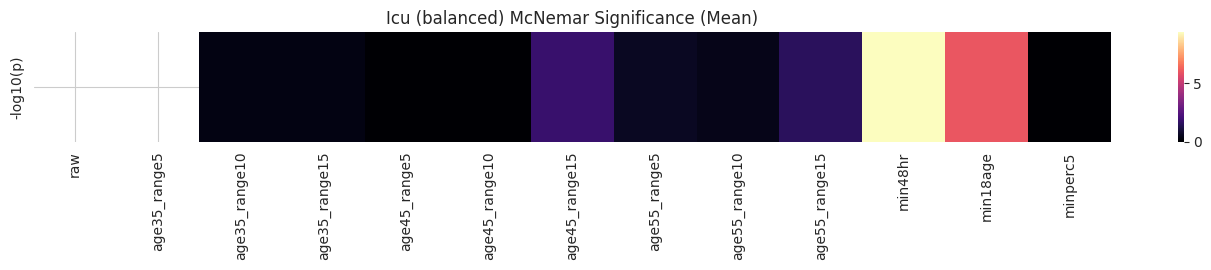

Balanced eval variant=age35_range5 target=mortality method=mean
Balanced eval variant=age35_range10 target=mortality method=mean


Balanced eval variant=age35_range15 target=mortality method=mean


Balanced eval variant=age45_range5 target=mortality method=mean
Balanced eval variant=age45_range10 target=mortality method=mean


Balanced eval variant=age45_range15 target=mortality method=mean


Balanced eval variant=age55_range5 target=mortality method=mean


...

Balanced eval variant=minperc5 target=mortality method=mean


Mortality Balanced Sample Sizes Using Mean Aggregation


,Filter Name,Balanced N
0,raw,6608
1,age35_range5,58
2,age35_range10,164
3,age35_range15,238
4,age45_range5,168
5,age45_range10,434
6,age45_range15,622
7,age55_range5,326
8,age55_range10,822
9,age55_range15,1182


Mortality (balanced) McNemar Results Using Mean Aggregation


,Filter Name,Avg Train Acc,Avg Test Acc,Avg Train Precision,Avg Test Precision,Avg Train Recall,Avg Test Recall,Avg Train F1,Avg Test F1,"McNemar (Stat, p)"
0,raw,0.732832,0.745840,0.750917,0.769674,0.696841,0.701589,0.722867,0.734023,—
1,age35_range5,0.888889,0.692308,0.875000,1.000000,0.823529,0.666667,0.848485,0.800000,0.2 (p=1.000e+00)
2,age35_range10,0.860807,0.685516,0.859430,0.980769,0.812842,0.670833,0.835139,0.791705,0.2 (p=3.750e-01)
3,age35_range15,0.792062,0.613210,0.803166,0.956345,0.699681,0.602589,0.747812,0.737121,0.1 (p=6.250e-01)
4,age45_range5,0.846993,0.741667,0.874491,1.000000,0.779056,0.690508,0.823969,0.805457,0.4 (p=2.500e-01)
5,age45_range10,0.815957,0.704844,0.833417,0.958565,0.741870,0.699517,0.784965,0.807094,0.5 (p=2.188e-01)
6,age45_range15,0.801681,0.731200,0.826037,0.994444,0.712523,0.710299,0.765075,0.827752,0.4 (p=2.891e-01)
7,age55_range5,0.776358,0.626010,0.790974,0.940774,0.685337,0.623053,0.734352,0.745229,1.8 (p=3.125e-02)
8,age55_range10,0.755534,0.672170,0.772394,0.972882,0.647232,0.657219,0.704238,0.783223,0.8 (p=1.250e-01)
9,age55_range15,0.758550,0.646038,0.774820,0.970548,0.655228,0.620437,0.710006,0.756437,1.7 (p=7.385e-03)


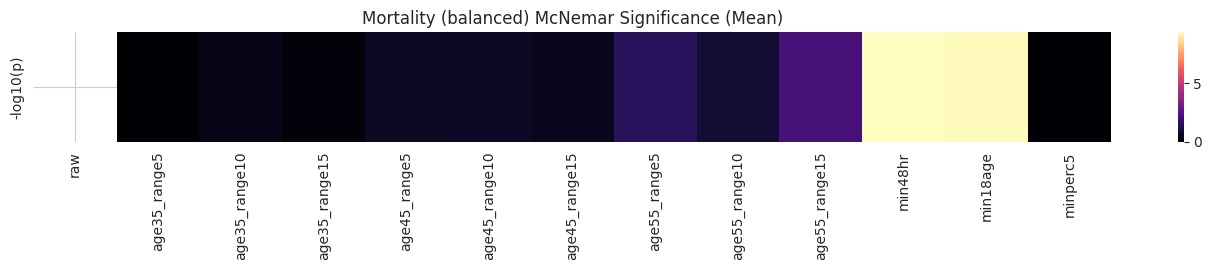

In [9]:
def make_balanced_patients_subset(patients_df, target_label, seed=0):
    """Return a class-balanced subset with equal positives/negatives."""
    y = _select_pos_label(patients_df, target_label)
    y = y.dropna().astype(int)

    pos_ids = y.index[y.values == 1]
    neg_ids = y.index[y.values == 0]

    n_per_class = min(len(pos_ids), len(neg_ids))
    if n_per_class == 0:
        return patients_df.iloc[0:0].copy()

    rng = np.random.default_rng(seed)
    pos_sel = rng.choice(np.asarray(pos_ids), size=n_per_class, replace=False)
    neg_sel = rng.choice(np.asarray(neg_ids), size=n_per_class, replace=False)
    keep_ids = pd.Index(np.concatenate([pos_sel, neg_sel]))

    return patients_df.loc[patients_df.index.intersection(keep_ids)]


def evaluate_balanced_for_method(method, target_label, max_variants=None, balance_seed=0):
    base_pat_all = maybe_sample_record_ids(BASELINE['patients'], MAX_RECORDS_PER_SCENARIO)
    base_pat = make_balanced_patients_subset(base_pat_all, target_label, seed=balance_seed)
    y_base = _select_pos_label(base_pat, target_label)

    # Subset time-series before aggregation
    X_base_full = BASELINE['X']
    X_base_small = subset_X_by_patients(X_base_full, base_pat)
    X_base_agg = build_record_aggregated_features(X_base_small, method).loc[base_pat.index]

    raw_metrics = {
        'train_acc':[], 'test_acc':[],
        'train_precision':[], 'test_precision':[],
        'train_recall':[], 'test_recall':[],
        'train_f1':[], 'test_f1':[]
    }
    raw_preds_by_seed = {}

    idx = X_base_agg.index
    for seed in SEEDS:
        if len(idx) < 20 or y_base.loc[idx].nunique() < 2:
            continue

        train_ids, test_ids = train_test_split(
            idx,
            test_size=TEST_SIZE,
            random_state=seed,
            stratify=y_base.loc[idx].values,
        )
        X_tr = X_base_agg.loc[train_ids]
        X_te = X_base_agg.loc[test_ids]
        y_tr = y_base.loc[train_ids].values
        y_te = y_base.loc[test_ids].values

        X_trs, scaler, col_means = impute_and_scale(X_tr)
        X_te = X_te.replace([np.inf, -np.inf], np.nan)
        X_te = X_te.fillna(col_means)
        X_te = X_te.fillna(0.0)
        X_tes = scaler.transform(X_te.values)

        clf = LogisticRegression(**MODEL_KWARGS)
        if len(np.unique(y_tr)) < 2:
            continue
        clf.fit(X_trs, y_tr)

        pred_tr = clf.predict(X_trs)
        pred_te = clf.predict(X_tes)

        raw_metrics['train_acc'].append(accuracy_score(y_tr, pred_tr))
        raw_metrics['test_acc'].append(accuracy_score(y_te, pred_te))
        raw_metrics['train_precision'].append(precision_score(y_tr, pred_tr, zero_division=0))
        raw_metrics['test_precision'].append(precision_score(y_te, pred_te, zero_division=0))
        raw_metrics['train_recall'].append(recall_score(y_tr, pred_tr, zero_division=0))
        raw_metrics['test_recall'].append(recall_score(y_te, pred_te, zero_division=0))
        raw_metrics['train_f1'].append(f1_score(y_tr, pred_tr, zero_division=0))
        raw_metrics['test_f1'].append(f1_score(y_te, pred_te, zero_division=0))

        raw_preds_by_seed[seed] = (test_ids, pred_te)

    results = {
        'raw': {
            'train_acc': float(np.mean(raw_metrics['train_acc'])) if raw_metrics['train_acc'] else np.nan,
            'test_acc': float(np.mean(raw_metrics['test_acc'])) if raw_metrics['test_acc'] else np.nan,
            'train_precision': float(np.mean(raw_metrics['train_precision'])) if raw_metrics['train_precision'] else np.nan,
            'test_precision': float(np.mean(raw_metrics['test_precision'])) if raw_metrics['test_precision'] else np.nan,
            'train_recall': float(np.mean(raw_metrics['train_recall'])) if raw_metrics['train_recall'] else np.nan,
            'test_recall': float(np.mean(raw_metrics['test_recall'])) if raw_metrics['test_recall'] else np.nan,
            'train_f1': float(np.mean(raw_metrics['train_f1'])) if raw_metrics['train_f1'] else np.nan,
            'test_f1': float(np.mean(raw_metrics['test_f1'])) if raw_metrics['test_f1'] else np.nan,
            'mcnemar': None,
            'n_balanced_records': int(len(base_pat)),
        }
    }

    variants = VARIANT_OBJS if max_variants is None else VARIANT_OBJS[:max_variants]
    for v in variants:
        print(f'Balanced eval variant={v["name"]} target={target_label} method={method}')

        v_pat_all = maybe_sample_record_ids(v['patients'], MAX_RECORDS_PER_SCENARIO)
        v_pat = make_balanced_patients_subset(v_pat_all, target_label, seed=balance_seed)
        y_v = _select_pos_label(v_pat, target_label)

        X_v_full = v.get('X', None)
        if X_v_full is None:
            X_v_full = pd.read_hdf(str(v['datafile']), 'vitals_labs')
        X_v_small = subset_X_by_patients(X_v_full, v_pat)
        X_v_agg = build_record_aggregated_features(X_v_small, method).loc[v_pat.index]

        metrics = {
            'train_acc':[], 'test_acc':[],
            'train_precision':[], 'test_precision':[],
            'train_recall':[], 'test_recall':[],
            'train_f1':[], 'test_f1':[]
        }
        mstats = []

        for seed in SEEDS:
            if seed not in raw_preds_by_seed:
                continue
            base_test_ids, base_pred = raw_preds_by_seed[seed]
            test_ids_v = v_pat.index.intersection(base_test_ids)
            if len(test_ids_v) < 10:
                continue

            train_ids_v = v_pat.index.difference(test_ids_v)
            if len(train_ids_v) < 10:
                continue

            X_tr = X_v_agg.loc[train_ids_v]
            X_te = X_v_agg.loc[test_ids_v]
            y_tr = y_v.loc[train_ids_v].values
            y_te = y_v.loc[test_ids_v].values

            X_trs, scaler, col_means = impute_and_scale(X_tr)
            X_te = X_te.replace([np.inf, -np.inf], np.nan)
            X_te = X_te.fillna(col_means)
            X_te = X_te.fillna(0.0)
            X_tes = scaler.transform(X_te.values)

            clf = LogisticRegression(**MODEL_KWARGS)
            if len(np.unique(y_tr)) < 2:
                continue
            clf.fit(X_trs, y_tr)
            pred_tr = clf.predict(X_trs)
            pred_te = clf.predict(X_tes)

            metrics['train_acc'].append(accuracy_score(y_tr, pred_tr))
            metrics['test_acc'].append(accuracy_score(y_te, pred_te))
            metrics['train_precision'].append(precision_score(y_tr, pred_tr, zero_division=0))
            metrics['test_precision'].append(precision_score(y_te, pred_te, zero_division=0))
            metrics['train_recall'].append(recall_score(y_tr, pred_tr, zero_division=0))
            metrics['test_recall'].append(recall_score(y_te, pred_te, zero_division=0))
            metrics['train_f1'].append(f1_score(y_tr, pred_tr, zero_division=0))
            metrics['test_f1'].append(f1_score(y_te, pred_te, zero_division=0))

            base_pred_map = pd.Series(base_pred, index=pd.Index(base_test_ids))
            var_pred_map = pd.Series(pred_te, index=pd.Index(test_ids_v))
            common_ids = test_ids_v
            stat, p = mcnemar_test(base_pred_map.loc[common_ids].values, var_pred_map.loc[common_ids].values)
            mstats.append((stat, p))

        results[v['name']] = {
            'train_acc': float(np.mean(metrics['train_acc'])) if metrics['train_acc'] else np.nan,
            'test_acc': float(np.mean(metrics['test_acc'])) if metrics['test_acc'] else np.nan,
            'train_precision': float(np.mean(metrics['train_precision'])) if metrics['train_precision'] else np.nan,
            'test_precision': float(np.mean(metrics['test_precision'])) if metrics['test_precision'] else np.nan,
            'train_recall': float(np.mean(metrics['train_recall'])) if metrics['train_recall'] else np.nan,
            'test_recall': float(np.mean(metrics['test_recall'])) if metrics['test_recall'] else np.nan,
            'train_f1': float(np.mean(metrics['train_f1'])) if metrics['train_f1'] else np.nan,
            'test_f1': float(np.mean(metrics['test_f1'])) if metrics['test_f1'] else np.nan,
            'mcnemar': (
                float(np.mean([s for s,_ in mstats])) if mstats else np.nan,
                float(np.min([p for _,p in mstats])) if mstats else np.nan,
            ),
            'n_balanced_records': int(len(v_pat)),
        }

        try:
            del X_v_full, X_v_small, X_v_agg
        except Exception:
            pass

    return results


def show_balanced_sample_sizes(results_dict, target_label, method):
    names = ['raw'] + [n for n in results_dict.keys() if n != 'raw']
    rows = []
    for n in names:
        rows.append({'Filter Name': n, 'Balanced N': results_dict[n].get('n_balanced_records', np.nan)})
    print(f'{target_label.capitalize()} Balanced Sample Sizes Using {method.capitalize()} Aggregation')
    display(pd.DataFrame(rows))


print('Running balanced class evaluation using the same classifier architecture...')
for method in run_methods:
    for target_label in LABELS:
        balanced_res = evaluate_balanced_for_method(method, target_label=target_label, balance_seed=0)
        show_balanced_sample_sizes(balanced_res, target_label=target_label, method=method)
        show_results(balanced_res, target_label=f'{target_label} (balanced)', method=method)
        visualize_mcnemar_significance(balanced_res, target_label=f'{target_label} (balanced)', method=method)


# Centroid shift 

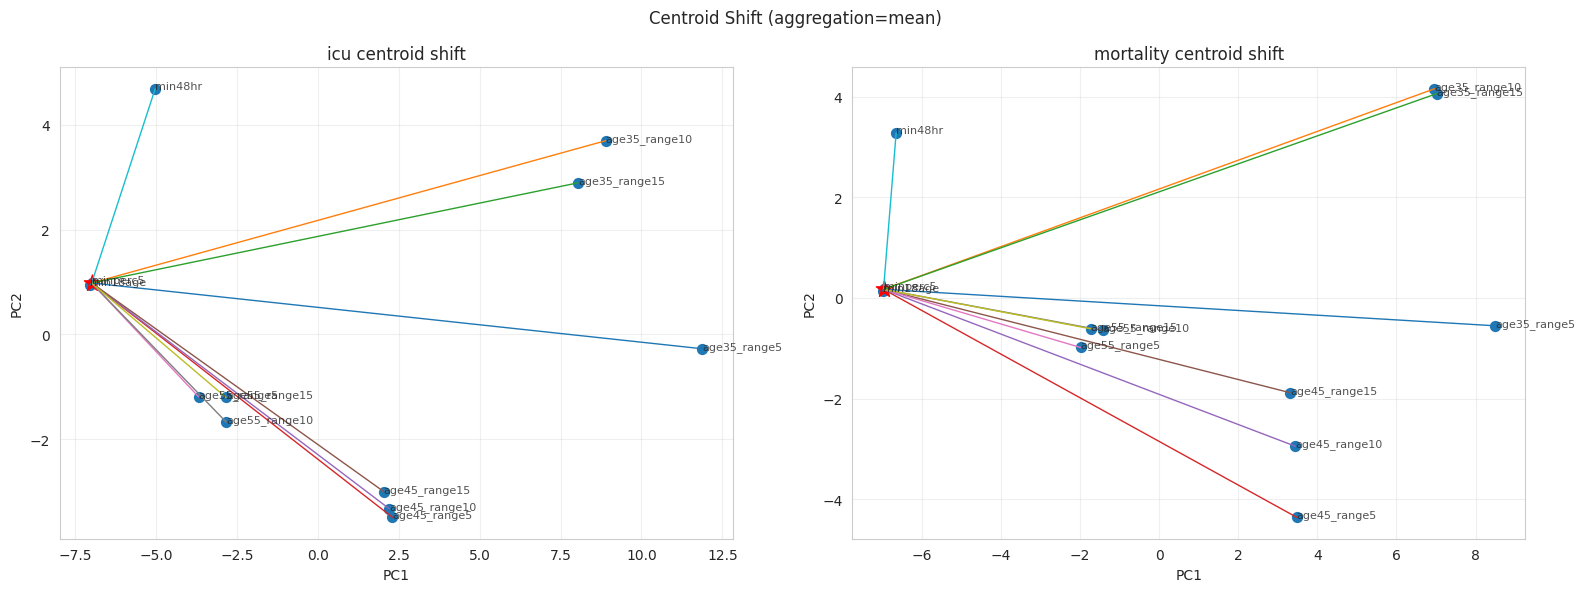

In [10]:
def compute_centroid(X_agg, patients_df, target_label):
    y = _select_pos_label(patients_df, target_label)
    y = y.loc[X_agg.index]
    sel = y.values == 1
    if sel.sum() == 0:
        return None
    vec = X_agg.loc[y.index[sel]].mean(axis=0).values
    # Guard against all-NaN feature columns after aggregation (can break PCA)
    vec = np.nan_to_num(vec, nan=0.0, posinf=0.0, neginf=0.0)
    return vec

def visualize_centroid_shift(method):
    base_pat = maybe_sample_record_ids(BASELINE['patients'], MAX_RECORDS_PER_SCENARIO)

    X_base_full = BASELINE['X']
    X_base_small = subset_X_by_patients(X_base_full, base_pat)
    X_base_agg = build_record_aggregated_features(X_base_small, method).loc[base_pat.index]

    cents_base = {lab: compute_centroid(X_base_agg, base_pat, lab) for lab in LABELS}

    variant_centroids = []
    for v in VARIANT_OBJS:
        pat = maybe_sample_record_ids(v['patients'], MAX_RECORDS_PER_SCENARIO)

        X_v_full = v.get('X', None)
        if X_v_full is None:
            X_v_full = pd.read_hdf(str(v['datafile']), 'vitals_labs')

        Xv_small = subset_X_by_patients(X_v_full, pat)
        Xv_agg = build_record_aggregated_features(Xv_small, method).loc[pat.index]
                # Align columns to baseline
        Xv_agg_aligned = Xv_agg.reindex(columns=X_base_agg.columns)
        cents = {lab: compute_centroid(Xv_agg_aligned, pat, lab) for lab in LABELS}
        variant_centroids.append({'name': v['name'], 'centroids': cents})

        # Free memory from the time-series load
        try:
            del X_v_full, Xv_small, Xv_agg
        except Exception:
            pass

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, lab in zip(axes, LABELS):
        vecs = []
        names = []
        if cents_base[lab] is None:
            ax.set_title(f'{lab} (no centroid)')
            continue
        vecs.append(cents_base[lab])
        names.append('raw(baseline)')

        for vc in variant_centroids:
            vvec = vc['centroids'].get(lab)
            if vvec is None:
                continue
            vecs.append(vvec)
            names.append(vc['name'])

        vecs = [np.nan_to_num(v, nan=0.0, posinf=0.0, neginf=0.0) for v in vecs]
        if len(vecs) < 2:
            # Not enough points for PCA(n_components=2)
            ax.scatter([0], [0], s=50)
            ax.scatter([0], [0], marker='*', s=150, c='red')
            ax.set_title(f'{lab} centroid shift (insufficient variants)')
            ax.set_xlabel('PC1')
            ax.set_ylabel('PC2')
            ax.grid(True, alpha=0.3)
            continue
        Z = PCA(n_components=2, random_state=0).fit_transform(np.vstack(vecs))
        base2 = Z[0]
        ax.scatter(Z[1:,0], Z[1:,1], s=50)
        ax.scatter([base2[0]], [base2[1]], marker='*', s=150, c='red')
        for i in range(1, len(Z)):
            ax.annotate(names[i], (Z[i,0], Z[i,1]), fontsize=8, alpha=0.8)
            ax.plot([base2[0], Z[i,0]], [base2[1], Z[i,1]], linewidth=1)
        ax.set_title(f'{lab} centroid shift')
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.grid(True, alpha=0.3)
    plt.suptitle(f'Centroid Shift (aggregation={method})')
    plt.tight_layout()
    plt.show()

for method in AGG_METHODS[:1]:
    visualize_centroid_shift(method)


# Extra visuals 

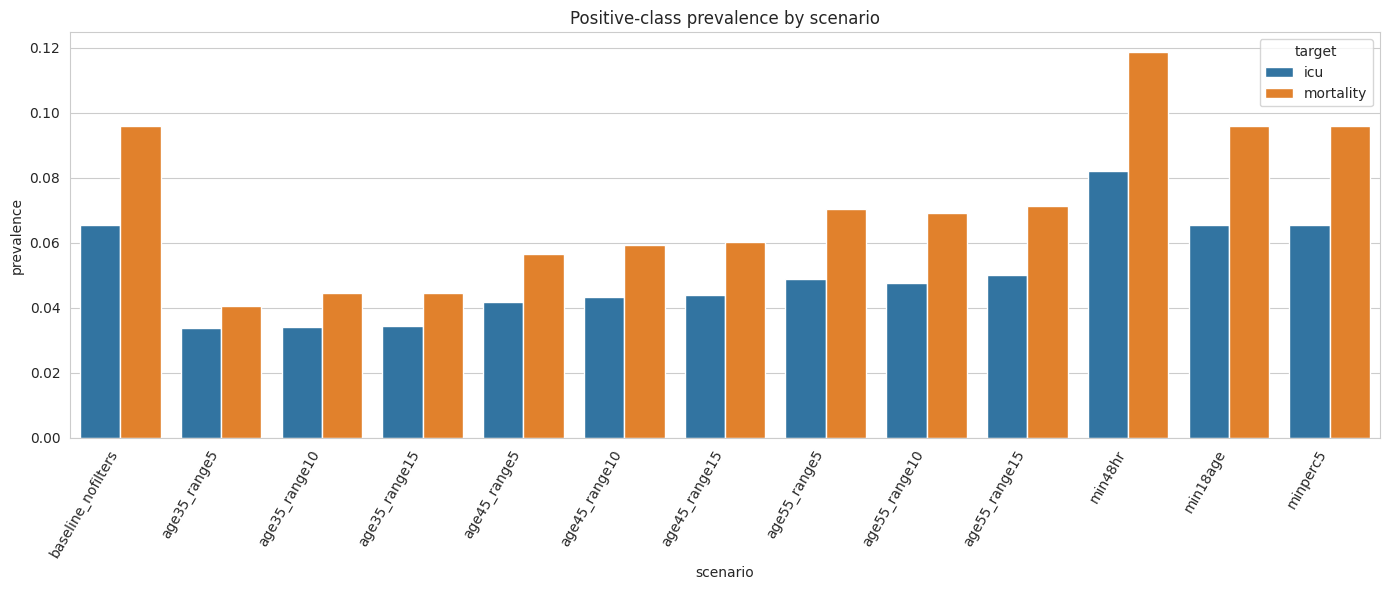

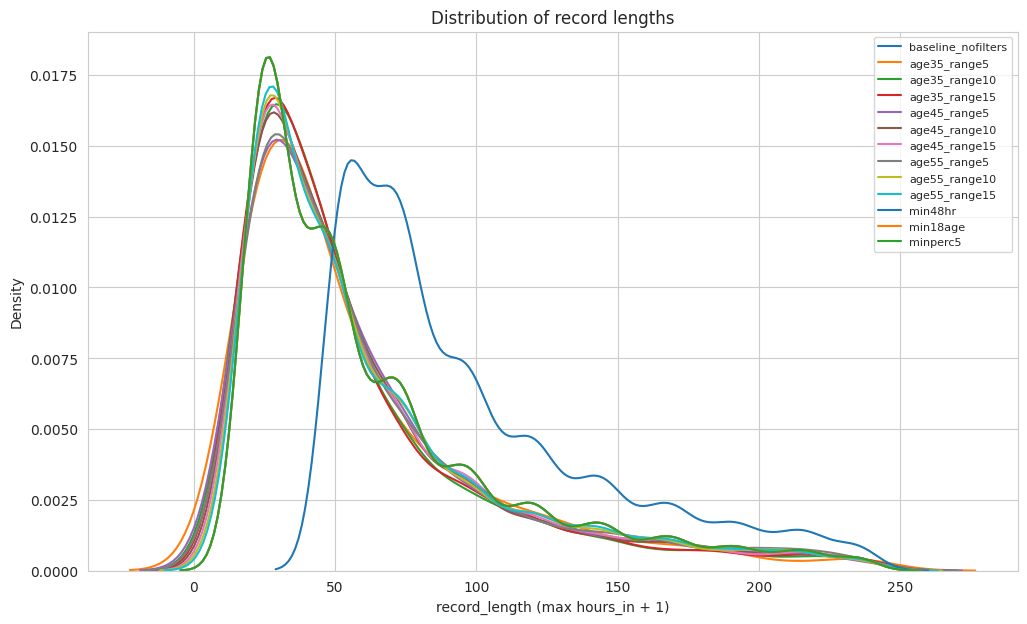

In [11]:
def fenceposts_to_record_lengths(scenario_dir, max_records=None):
    fp_path = scenario_dir / 'fenceposts.npy'
    fp = np.load(str(fp_path))
    if max_records is not None and len(fp) > max_records:
        rng = np.random.default_rng(0)
        fp = fp[rng.choice(len(fp), size=max_records, replace=False)]
    return fp + 1

rows = []
for v in [BASELINE] + VARIANT_OBJS:
    # Prevalence
    patients = v['patients']
    for lab in LABELS:
        y = _select_pos_label(patients, lab)
        rows.append({'scenario': v['name'], 'target': lab, 'prevalence': float(y.mean())})

df_prev = pd.DataFrame(rows)
plt.figure(figsize=(14, 6))
sns.barplot(data=df_prev, x='scenario', y='prevalence', hue='target')
plt.title('Positive-class prevalence by scenario')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
for v in [BASELINE] + VARIANT_OBJS:
    scenario_dir = Path(v['datafile']).parent
    lens = fenceposts_to_record_lengths(scenario_dir, max_records=MAX_RECORDS_PER_SCENARIO)
    sns.kdeplot(lens, label=v['name'], warn_singular=False)
plt.title('Distribution of record lengths')
plt.xlabel('record_length (max hours_in + 1)')
plt.legend(fontsize=8)
plt.show()
